## 4 neighbors automata

{15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0, 6: 0, 5: 0, 4: 1, 3: 1, 2: 1, 1: 1, 0: 0}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0]


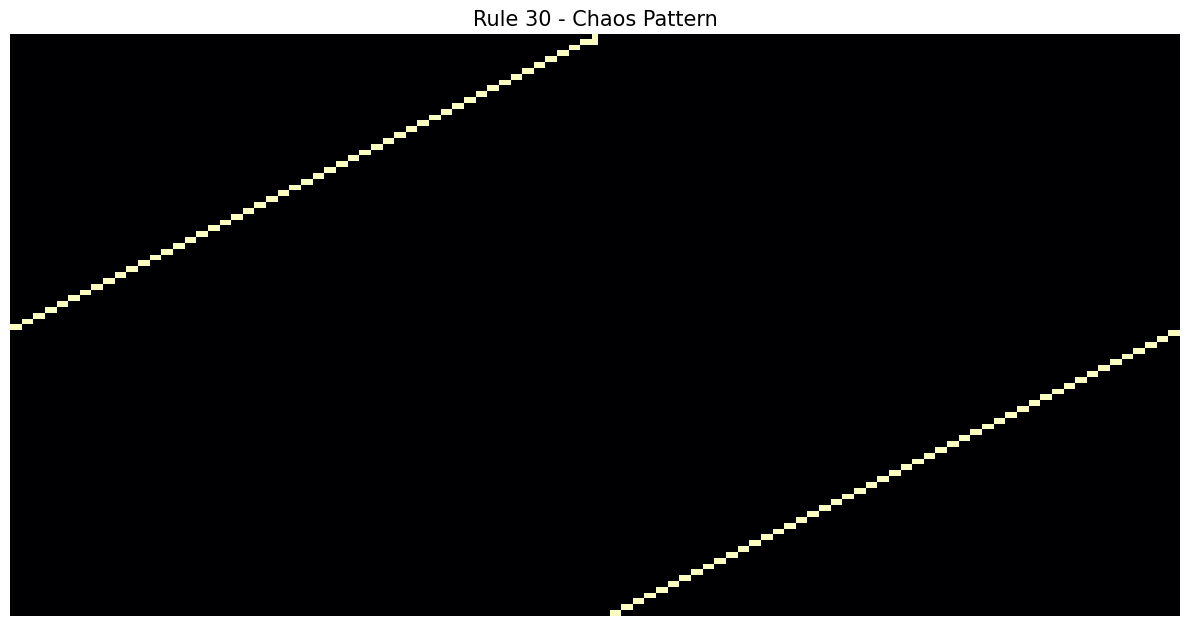

{15: 1, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0, 6: 1, 5: 0, 4: 1, 3: 1, 2: 0, 1: 1, 0: 0}
[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0]


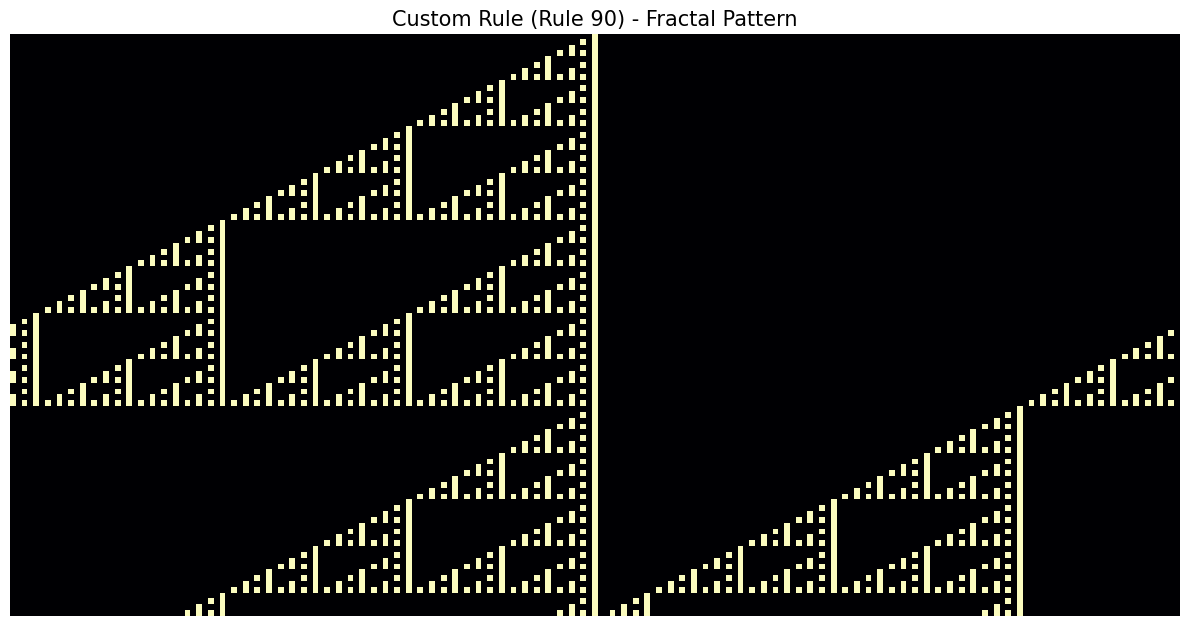

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# provide with 4 parameters realizing specified rules, grid size, iteration and initial cells)
def generate_ca(rule_input, width=100, steps=50, init_row=None):

    if isinstance(rule_input, int): # a built-in function 'isinstance' to judge if instance int type
        # if input int, transfer decimal input to binary, and compulsory as a list with 8 bits
        rule_bin = [int(x) for x in np.binary_repr(rule_input, width=16)]
    else:
        # given a standard mapping pattern starting with '111' corresponding to the digit of 2**(8-1) end with '000' which is 2**0
        # if input not int, default as strings and judge corresponding to which digit those combination given in input that lead to live
        patterns = ['1111', '1110', '1101', '1100', '1011', '1010', '1001', '1000'
                    , '0111', '0110', '0101', '0100', '0011', '0010', '0001', '0000']
        rule_bin = [1 if p in rule_input else 0 for p in patterns]

    # above we got a list with 8 elements consist of 1 or 0, now we create a dict: key of dict is the index of the list 'rule_bin' which means the combination to be judged, and the value of dict is the value of the list 'rule_bin' which means the judgement survive(1) or die(0).
    # for example if the value of index = 0 in rule_bin is 0, index = 0 means combination '111' and value = 0 means to be judged as death
    # enumerate gives index to each element in rule_bin and return 8 tuple starting with (0,v)
    # 7-i inverses the indices' order as key's order because smaller key refers to larger combination (7 refers to '111'), v as value. loop i, v in tuples
    rule_map = {15-i: v for i, v in enumerate(rule_bin)}

    # define an all-zero array, with storage type as int (only 0 or 1)
    history = np.zeros((steps, width), dtype=int)
    # if the parameter of first row(initial) is given, us the given one
    if init_row is not None:
        history[0] = init_row
    # if not given, set only the midpoint as 0 in first row
    else:
        history[0, width // 2] = 1  # 默认中间一个点为 1

    # loop for steps given, starting from 0
    for t in range(steps - 1):
        # for each iteration(step), obtain a value for cells(left, self and right) by row indices(t) and column indices(width) and %obtains mod to keep boundaries continuous
        for i in range(width):
            # 获取左、中、右邻居，使用取模运算实现循环边界 (Periodic Boundary)
            left  = history[t, (i - 1) % width]
            mid   = history[t, i]
            right1 = history[t, (i + 1) % width]
            right2 = history[t, (i + 2) % width]

            # to avoid internal storage type transferring(int to string, string to int), using shift to move bits of left and self. concat them as combination, and transfer to decimal for judging--<<2 equals to *4; <<1 equals to *2
            idx = (left << 3) | (mid << 2) | (right1 <<1) | right2
            # locating each of cells to be updating next iteration, and give idx as key to the dict, obtain the value(1 or 0--survive or die)
            history[t + 1, i] = rule_map[idx]

    print(rule_map)
    print(rule_bin)
    return history


def plot_ca(data, title="Cellular Automata"):
    plt.figure(figsize=(12, 8))
    # 使用 'binary' 或者是 'magma' 等色标，插值选 'nearest' 保证像素感
    plt.imshow(data, cmap='magma', interpolation='nearest')
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- 使用示例 ---

# 示例 A：输入 Rule 30 编号
data_30 = generate_ca(rule_input=30, width=201, steps=100)
plot_ca(data_30, "Rule 30 - Chaos Pattern")

# 示例 B：输入 8 个由 01 构成的字符串 (模拟 Rule 90: 只有左右不同时为1)
# Rule 90 对应的 1 模式是：110, 100, 011, 001
rule_90_patterns = ['0110', '0100', '0011', '0001', '1111']
data_custom = generate_ca(rule_input=rule_90_patterns, width=201, steps=100)
plot_ca(data_custom, "Custom Rule (Rule 90) - Fractal Pattern")

# 5 neighbors

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0, 6: 0, 5: 0, 4: 1, 3: 1, 2: 1, 1: 1, 0: 0}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0]


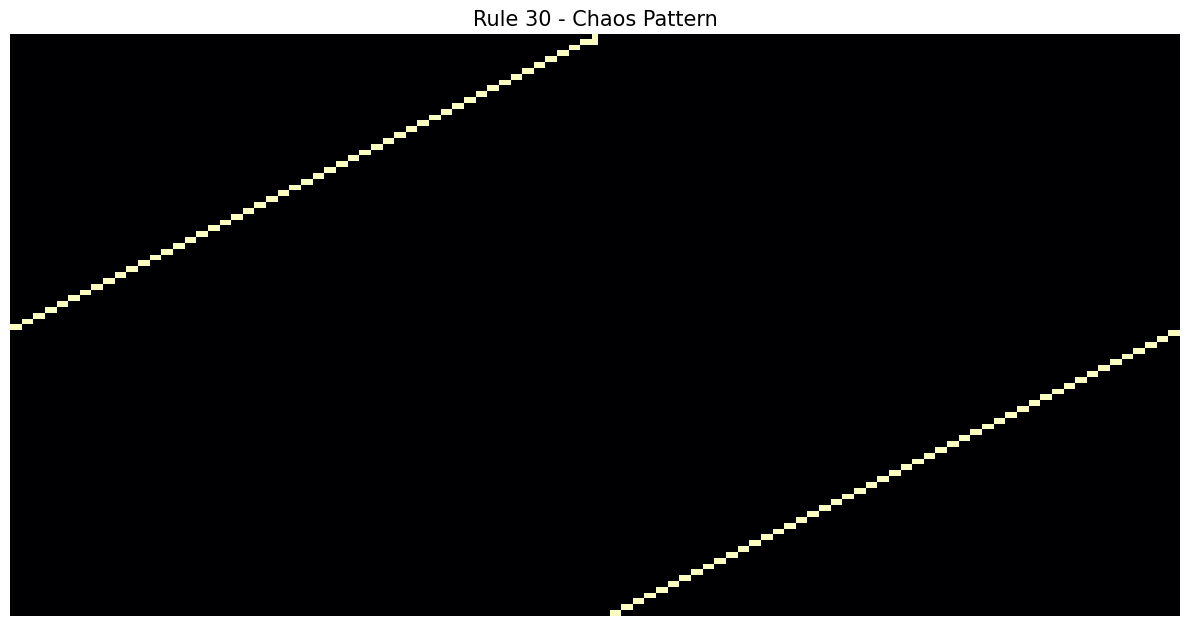

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 1, 8: 1, 7: 1, 6: 1, 5: 1, 4: 1, 3: 0, 2: 1, 1: 0, 0: 0}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]


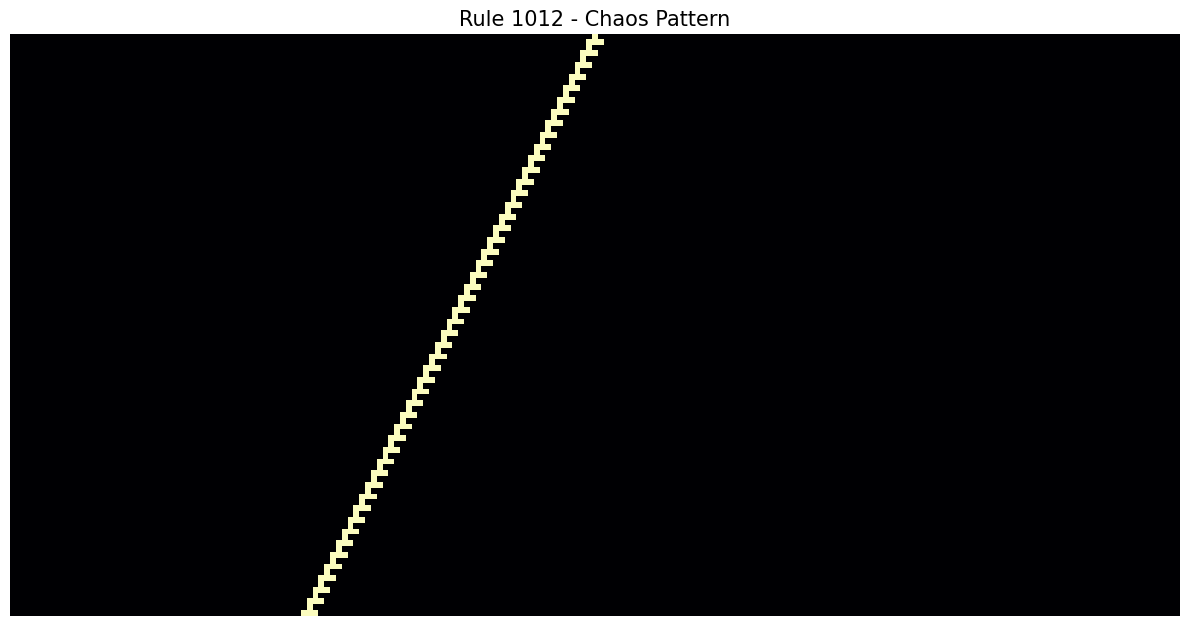

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 1, 8: 1, 7: 1, 6: 1, 5: 1, 4: 0, 3: 0, 2: 1, 1: 1, 0: 1}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]


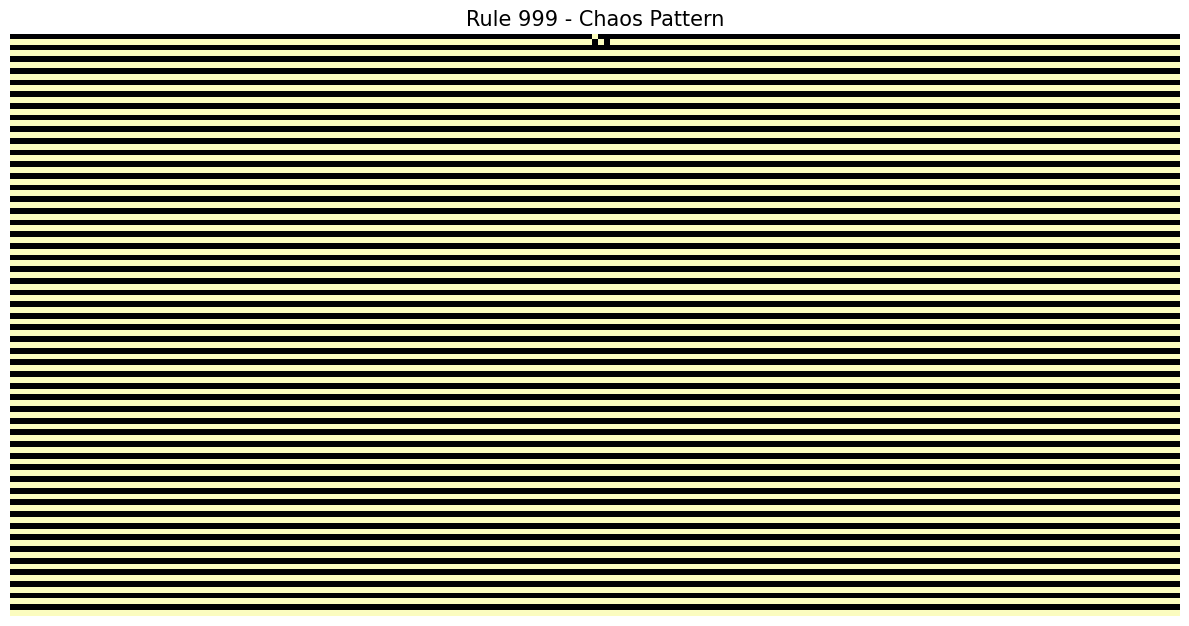

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 1, 7: 0, 6: 1, 5: 0, 4: 0, 3: 1, 2: 0, 1: 1, 0: 0}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0]


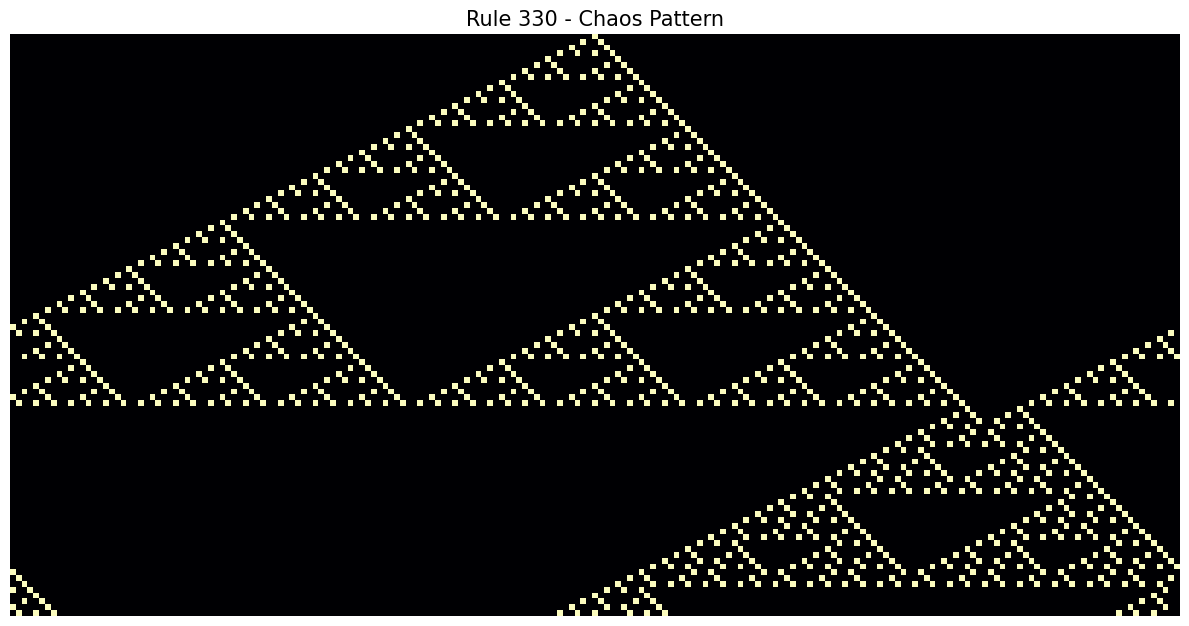

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0, 6: 1, 5: 1, 4: 1, 3: 1, 2: 0, 1: 0, 0: 0}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0]


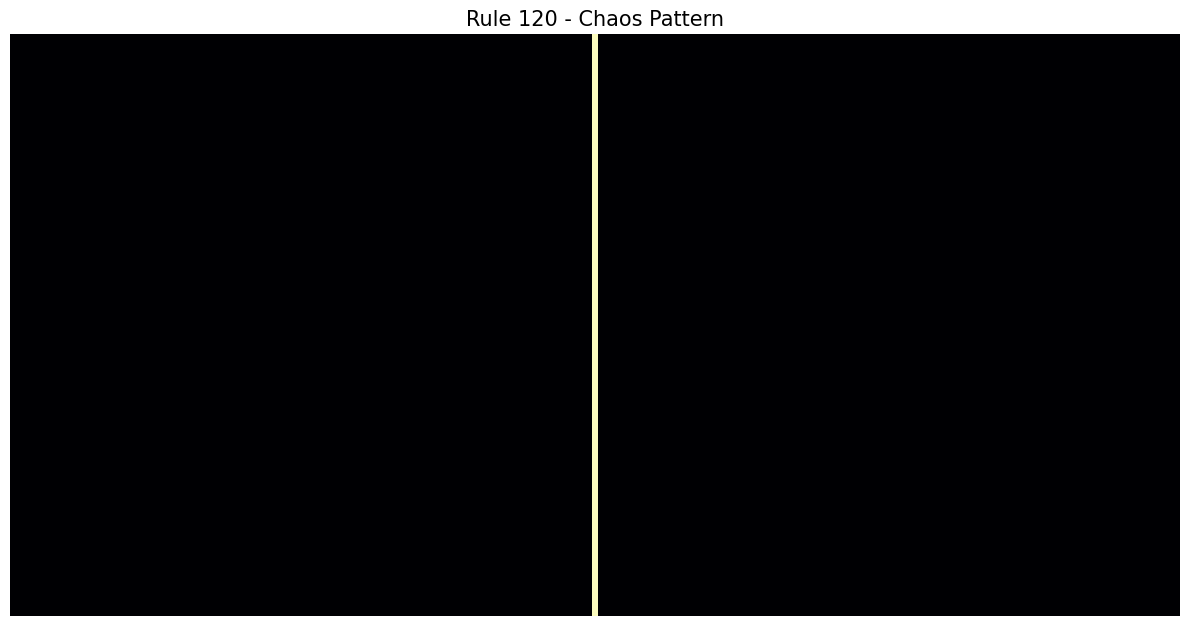

{31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 1, 7: 0, 6: 1, 5: 1, 4: 0, 3: 1, 2: 0, 1: 0, 0: 1}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1]


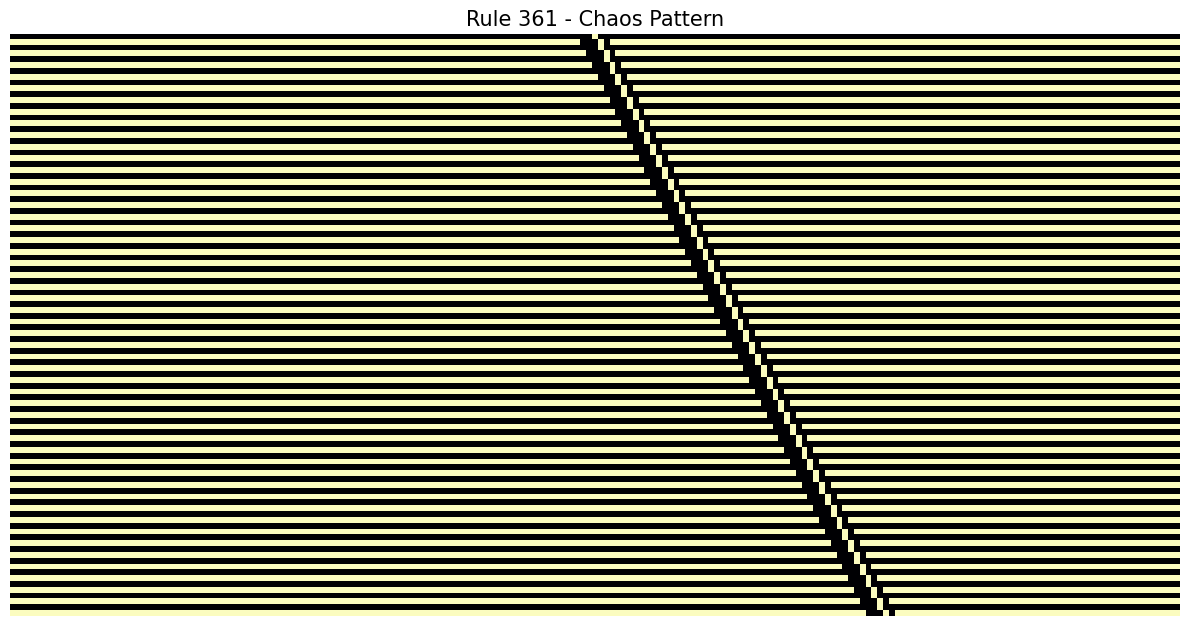

{31: 1, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 1, 21: 0, 20: 1, 19: 1, 18: 0, 17: 1, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0, 6: 0, 5: 0, 4: 0, 3: 0, 2: 0, 1: 0, 0: 0}
[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


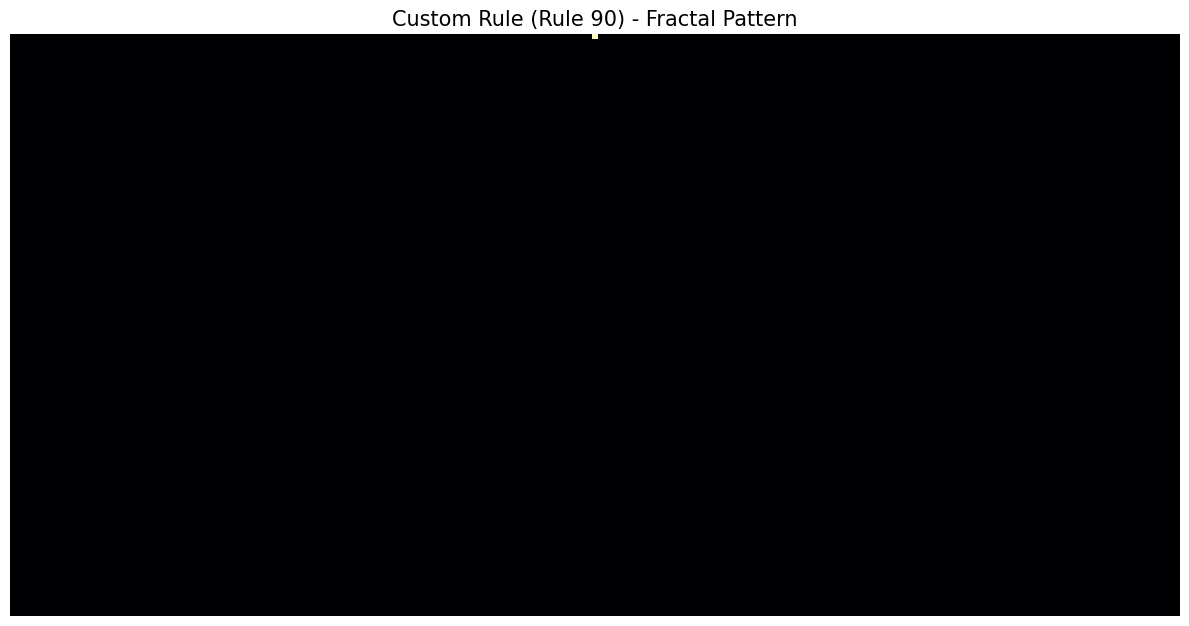

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# provide with 4 parameters realizing specified rules, grid size, iteration and initial cells)
def generate_ca(rule_input, width=100, steps=50, init_row=None):

    if isinstance(rule_input, int): # a built-in function 'isinstance' to judge if instance int type
        # if input int, transfer decimal input to binary, and compulsory as a list with 8 bits
        rule_bin = [int(x) for x in np.binary_repr(rule_input, width=32)]
    else:
        # given a standard mapping pattern starting with '111' corresponding to the digit of 2**(8-1) end with '000' which is 2**0
        # if input not int, default as strings and judge corresponding to which digit those combination given in input that lead to live
        patterns = ['11111', '11110', '11101', '11100', '11011', '11010', '11001', '11000'
                    , '10111', '10110', '10101', '10100', '10011', '10010', '10001', '10000'
                    , '01111', '01110', '01101', '01100', '01011', '01010', '01001', '01000'
                    , '00111', '00110', '00101', '00100', '00011', '00010', '00001', '00000']
        rule_bin = [1 if p in rule_input else 0 for p in patterns]

    # above we got a list with 8 elements consist of 1 or 0, now we create a dict: key of dict is the index of the list 'rule_bin' which means the combination to be judged, and the value of dict is the value of the list 'rule_bin' which means the judgement survive(1) or die(0).
    # for example if the value of index = 0 in rule_bin is 0, index = 0 means combination '111' and value = 0 means to be judged as death
    # enumerate gives index to each element in rule_bin and return 8 tuple starting with (0,v)
    # 7-i inverses the indices' order as key's order because smaller key refers to larger combination (7 refers to '111'), v as value. loop i, v in tuples
    rule_map = {31-i: v for i, v in enumerate(rule_bin)}

    # define an all-zero array, with storage type as int (only 0 or 1)
    history = np.zeros((steps, width), dtype=int)
    # if the parameter of first row(initial) is given, us the given one
    if init_row is not None:
        history[0] = init_row
    # if not given, set only the midpoint as 0 in first row
    else:
        history[0, width // 2] = 1  # 默认中间一个点为 1

    # loop for steps given, starting from 0
    for t in range(steps - 1):
        # for each iteration(step), obtain a value for cells(left, self and right) by row indices(t) and column indices(width) and %obtains mod to keep boundaries continuous
        for i in range(width):
            # 获取左、中、右邻居，使用取模运算实现循环边界 (Periodic Boundary)
            left2  = history[t, (i - 2) % width]
            left1 = history[t, (i - 1) % width]
            mid   = history[t, i]
            right1 = history[t, (i + 1) % width]
            right2 = history[t, (i + 2) % width]

            # to avoid internal storage type transferring(int to string, string to int), using shift to move bits of left and self. concat them as combination, and transfer to decimal for judging--<<2 equals to *4; <<1 equals to *2
            idx = (left2 << 4) | (left1 << 3) | (mid << 2) | (right1 <<1) | right2
            # locating each of cells to be updating next iteration, and give idx as key to the dict, obtain the value(1 or 0--survive or die)
            history[t + 1, i] = rule_map[idx]

    print(rule_map)
    print(rule_bin)
    return history


def plot_ca(data, title="Cellular Automata"):
    plt.figure(figsize=(12, 8))
    # 使用 'binary' 或者是 'magma' 等色标，插值选 'nearest' 保证像素感
    plt.imshow(data, cmap='magma', interpolation='nearest')
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- 使用示例 ---

# 示例 A：输入 Rule 30 编号
data_30 = generate_ca(rule_input=30, width=201, steps=100)
plot_ca(data_30, "Rule 30 - Chaos Pattern")

data_1012 = generate_ca(rule_input=1012, width=201, steps=100)
plot_ca(data_1012, "Rule 1012 - Chaos Pattern")

data_999 = generate_ca(rule_input=999, width=201, steps=100)
plot_ca(data_999, "Rule 999 - Chaos Pattern")

data_330 = generate_ca(rule_input=330, width=201, steps=100)
plot_ca(data_330, "Rule 330 - Chaos Pattern")

data_120 = generate_ca(rule_input=120, width=201, steps=100)
plot_ca(data_120, "Rule 120 - Chaos Pattern")

data_361 = generate_ca(rule_input=361, width=201, steps=100)
plot_ca(data_361, "Rule 361 - Chaos Pattern")

# 示例 B：输入 8 个由 01 构成的字符串 (模拟 Rule 90: 只有左右不同时为1)
# Rule 90 对应的 1 模式是：110, 100, 011, 001
rule_90_patterns = ['10110', '10100', '10011', '10001', '11111']
data_custom = generate_ca(rule_input=rule_90_patterns, width=201, steps=100)
plot_ca(data_custom, "Custom Rule (Rule 90) - Fractal Pattern")